# The Runs Test: Is Your Return Series Actually Random?

**Cordell Tanny, CFA, FRM, FDP**  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny/quant-finance-snippets](https://github.com/ctanny/quant-finance-snippets)

---

Most quants test for autocorrelation when they want to know if a return series has structure. That is a reasonable starting point. But autocorrelation only catches linear dependencies. If the market has nonlinear structure, or if the pattern of ups and downs is non-random in a way that autocorrelation misses, you will not find it there.

The Wald-Wolfowitz runs test is a simple, elegant alternative. It asks a different question: does the sequence of positive and negative returns look like what you would expect from a random process? No distribution assumptions required. No linear dependence required. Just the sequence of signs.

It is obscure. It is underused. And for certain strategy research questions, it is exactly the right tool.

What this notebook covers:
1. What a run is and why it matters
2. The runs test on SPY: is the market random?
3. A rolling runs test to see how market structure changes over time

> Note on data: we use SPY log returns throughout, consistent with the rest of this series.


## 1. Imports and Setup

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Parameters ─────────────────────────────────────────────────────────────
TICKER         = 'SPY'
START_DATE     = '2005-01-01'
ROLLING_WINDOW = 252   # 1 year rolling window for the rolling test
ALPHA          = 0.05  # significance level

In [2]:
raw     = yf.download(TICKER, start=START_DATE, auto_adjust=True, progress=False)['Close'].squeeze()
returns = np.log(raw / raw.shift(1)).dropna()

print(f"Asset       : {TICKER}")
print(f"Period      : {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Observations: {len(returns)} trading days")
print(f"Positive days: {(returns > 0).sum()} ({(returns > 0).mean():.1%})")
print(f"Negative days: {(returns < 0).sum()} ({(returns < 0).mean():.1%})")

Asset       : SPY
Period      : 2005-01-04 to 2026-06-01
Observations: 5385 trading days
Positive days: 2970 (55.2%)
Negative days: 2399 (44.5%)


## 2. What Is a Run?

A run is a consecutive sequence of the same outcome. If SPY has three positive days in a row followed by two negative days followed by one positive day, that sequence contains three runs.

```
Returns:  +  +  +  -  -  +
Runs:     |--1--|  |-2-|  3
```

The key insight is this: if returns are truly random, the number of runs you observe should fall within a predictable range. Too few runs means the series is trending (long streaks of the same sign). Too many runs means the series is mean-reverting (the sign flips more often than chance would predict).

The Wald-Wolfowitz test formalizes this intuition. Given n+ positive returns and n- negative returns, it calculates the expected number of runs under the null hypothesis of randomness and tests whether the observed number of runs is consistent with that expectation.

Expected runs under randomness:

```
E[R] = (2 * n+ * n-) / (n+ + n-) + 1
```

The variance of R under the null:

```
Var[R] = (2 * n+ * n-) * (2 * n+ * n- - n+ - n-) / ((n+ + n-)^2 * (n+ + n- - 1))
```

For large samples, the test statistic (R - E[R]) / sqrt(Var[R]) follows a standard normal distribution, making it easy to compute a p-value.

What the result tells you:
- p-value < 0.05, fewer runs than expected: the series is trending. Momentum strategies may have an edge.
- p-value < 0.05, more runs than expected: the series is mean-reverting. Contrarian strategies may have an edge.
- p-value > 0.05: the sequence of ups and downs is consistent with randomness. No obvious structural edge from the sign sequence alone.

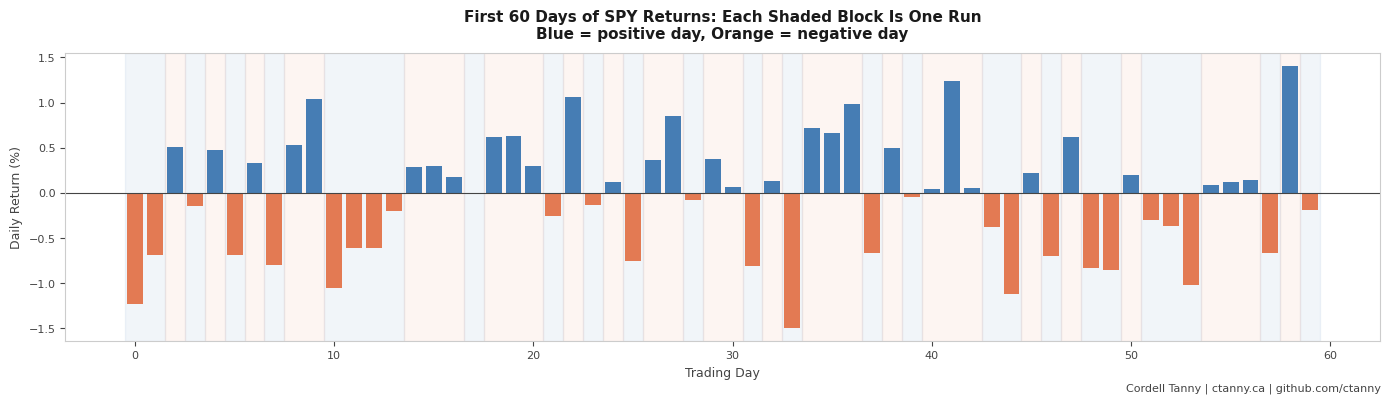

In [3]:
# Visualize what runs look like on a short window
sample = returns.iloc[:60]
signs  = np.sign(sample)

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

colors = ['#185FA5' if s > 0 else '#E05C2A' for s in signs]
ax.bar(range(len(sample)), sample * 100, color=colors, alpha=0.8, width=0.8)
ax.axhline(0, color='#444444', linewidth=0.8)

# Identify and shade runs
run_id    = 0
prev_sign = signs.iloc[0]
run_start = 0
shade     = False

for i, s in enumerate(signs):
    if s != prev_sign:
        ax.axvspan(run_start - 0.5, i - 0.5,
                   alpha=0.06, color='#185FA5' if not shade else '#E05C2A',
                   zorder=0)
        run_start = i
        prev_sign = s
        shade = not shade
        run_id += 1
ax.axvspan(run_start - 0.5, len(signs) - 0.5,
           alpha=0.06, color='#185FA5' if not shade else '#E05C2A', zorder=0)

ax.set_title(f'First 60 Days of SPY Returns: Each Shaded Block Is One Run\n'
             f'Blue = positive day, Orange = negative day',
             fontsize=11, fontweight='bold', color='#1a1a1a', pad=10)
ax.set_xlabel('Trading Day', fontsize=9, color='#444444')
ax.set_ylabel('Daily Return (%)', fontsize=9, color='#444444')
ax.tick_params(colors='#444444', labelsize=8)
for sp in ax.spines.values(): sp.set_edgecolor('#cccccc')

plt.figtext(0.99, 0.01, 'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
plt.savefig('runs_visual.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 3. The Runs Test on SPY

Now we apply the test to the full SPY return series. The null hypothesis is that the sequence of positive and negative returns is random. We are testing whether the observed number of runs is consistent with that assumption.

In [4]:
def runs_test(series):
    """
    Wald-Wolfowitz runs test for randomness.

    Tests whether the sequence of signs in a return series is consistent
    with the null hypothesis of randomness. Zero returns are excluded.

    Parameters
    ----------
    series : array-like of returns

    Returns
    -------
    dict with:
        n_runs    : observed number of runs
        expected  : expected runs under H0
        z_stat    : test statistic
        p_value   : two-sided p-value
        n_pos     : number of positive observations
        n_neg     : number of negative observations
    """
    s = np.array(series)
    s = s[s != 0]  # exclude zero returns
    signs = np.sign(s)

    n_pos = (signs == 1).sum()
    n_neg = (signs == -1).sum()
    n     = n_pos + n_neg

    # Count runs
    runs   = 1 + np.sum(signs[1:] != signs[:-1])

    # Expected runs and variance under H0
    expected = (2 * n_pos * n_neg) / n + 1
    variance = (2 * n_pos * n_neg * (2 * n_pos * n_neg - n)) / (n ** 2 * (n - 1))

    # Z-statistic with continuity correction
    z_stat  = (runs - expected) / np.sqrt(variance)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    return {
        'n_runs'  : runs,
        'expected': expected,
        'z_stat'  : z_stat,
        'p_value' : p_value,
        'n_pos'   : n_pos,
        'n_neg'   : n_neg,
    }


result = runs_test(returns)

print(f"WALD-WOLFOWITZ RUNS TEST: {TICKER}")
print("=" * 45)
print(f"Positive days     : {result['n_pos']}")
print(f"Negative days     : {result['n_neg']}")
print(f"Observed runs     : {result['n_runs']}")
print(f"Expected runs     : {result['expected']:.1f}")
print(f"Z-statistic       : {result['z_stat']:.4f}")
print(f"p-value           : {result['p_value']:.6f}")
print()
if result['p_value'] < ALPHA:
    direction = 'fewer' if result['z_stat'] < 0 else 'more'
    implication = 'trending structure' if result['z_stat'] < 0 else 'mean-reverting structure'
    print(f"Conclusion: Reject randomness (p < {ALPHA})")
    print(f"  {direction.capitalize()} runs than expected implies {implication}")
else:
    print(f"Conclusion: Cannot reject randomness (p = {result['p_value']:.4f})")
    print(f"  The sequence of up and down days is consistent with a random process")

WALD-WOLFOWITZ RUNS TEST: SPY
Positive days     : 2970
Negative days     : 2399
Observed runs     : 2708
Expected runs     : 2655.1
Z-statistic       : 1.4595
p-value           : 0.144414

Conclusion: Cannot reject randomness (p = 0.1444)
  The sequence of up and down days is consistent with a random process


## 4. Rolling Runs Test: How Market Structure Changes Over Time

A single test on the full sample tells you about the average behavior over 20 years. But market structure changes. The degree of randomness in SPY returns in 2008 was very different from 2017.

A rolling runs test applied to a one-year window at each point in time shows how the structure of the market evolved. When the p-value is low and the z-statistic is negative, the market was trending. When it is low and positive, the market was mean-reverting. When it is above 0.05, the market was behaving randomly with respect to the sequence of up and down days.

This is genuinely useful for strategy research. If you are building a momentum strategy, you want to know whether it was operating in an environment with trending structure or random structure. The answer changes the expected performance and should change how you evaluate your backtest.

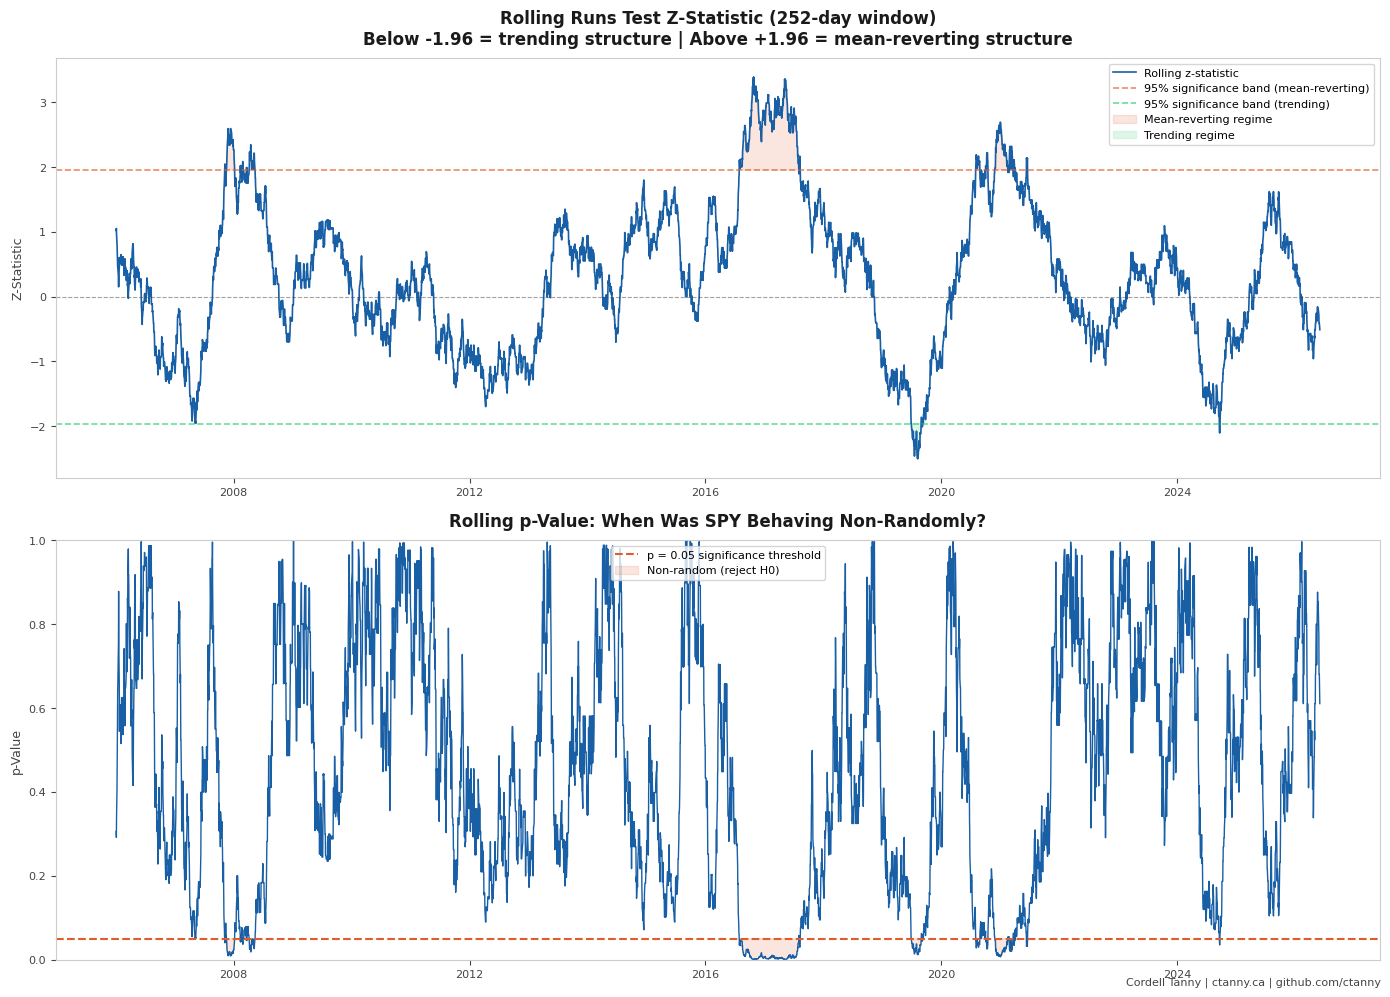

Rolling test summary (252-day window):
  Random (p > 0.05)       : 90.4% of windows
  Non-random total         : 9.6% of windows
  Trending structure       : 1.0% of windows
  Mean-reverting structure : 8.6% of windows


In [5]:
rolling_results = []
r_vals  = returns.values
r_index = returns.index

for i in range(ROLLING_WINDOW, len(r_vals)):
    window = r_vals[i - ROLLING_WINDOW: i]
    res    = runs_test(window)
    rolling_results.append({
        'date'   : r_index[i],
        'z_stat' : res['z_stat'],
        'p_value': res['p_value'],
        'n_runs' : res['n_runs'],
        'expected': res['expected'],
    })

df_roll = pd.DataFrame(rolling_results).set_index('date')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor('white')

# Top: rolling z-statistic with significance bands
axes[0].set_facecolor('white')
axes[0].plot(df_roll.index, df_roll['z_stat'],
             color='#185FA5', linewidth=1.2, label='Rolling z-statistic')
axes[0].axhline(0,     color='#444444', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].axhline(1.96,  color='#E05C2A', linewidth=1.2, linestyle='--',
                alpha=0.7, label='95% significance band (mean-reverting)')
axes[0].axhline(-1.96, color='#2ECC71', linewidth=1.2, linestyle='--',
                alpha=0.7, label='95% significance band (trending)')
axes[0].fill_between(df_roll.index, df_roll['z_stat'], 1.96,
                     where=df_roll['z_stat'] > 1.96,
                     color='#E05C2A', alpha=0.15, label='Mean-reverting regime')
axes[0].fill_between(df_roll.index, df_roll['z_stat'], -1.96,
                     where=df_roll['z_stat'] < -1.96,
                     color='#2ECC71', alpha=0.15, label='Trending regime')
axes[0].set_title(f'Rolling Runs Test Z-Statistic ({ROLLING_WINDOW}-day window)\n'
                  'Below -1.96 = trending structure | Above +1.96 = mean-reverting structure',
                  fontsize=12, fontweight='bold', color='#1a1a1a', pad=10)
axes[0].set_ylabel('Z-Statistic', fontsize=9, color='#444444')
axes[0].legend(fontsize=8, frameon=True, facecolor='white',
               edgecolor='#cccccc', loc='upper right')
axes[0].tick_params(colors='#444444', labelsize=8)
for sp in axes[0].spines.values(): sp.set_edgecolor('#cccccc')

# Bottom: rolling p-value with significance threshold
axes[1].set_facecolor('white')
axes[1].plot(df_roll.index, df_roll['p_value'],
             color='#185FA5', linewidth=1.0)
axes[1].axhline(ALPHA, color='#E05C2A', linewidth=1.5,
                linestyle='--', label=f'p = {ALPHA} significance threshold')
axes[1].fill_between(df_roll.index, df_roll['p_value'], ALPHA,
                     where=df_roll['p_value'] < ALPHA,
                     color='#E05C2A', alpha=0.15,
                     label='Non-random (reject H0)')
axes[1].set_title('Rolling p-Value: When Was SPY Behaving Non-Randomly?',
                  fontsize=12, fontweight='bold', color='#1a1a1a', pad=10)
axes[1].set_ylabel('p-Value', fontsize=9, color='#444444')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8, frameon=True, facecolor='white', edgecolor='#cccccc')
axes[1].tick_params(colors='#444444', labelsize=8)
for sp in axes[1].spines.values(): sp.set_edgecolor('#cccccc')

plt.figtext(0.99, 0.01, 'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
plt.savefig('runs_rolling.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

pct_nonrandom = (df_roll['p_value'] < ALPHA).mean()
pct_trending  = ((df_roll['p_value'] < ALPHA) & (df_roll['z_stat'] < 0)).mean()
pct_mreverting = ((df_roll['p_value'] < ALPHA) & (df_roll['z_stat'] > 0)).mean()

print(f"Rolling test summary ({ROLLING_WINDOW}-day window):")
print(f"  Random (p > {ALPHA})       : {1 - pct_nonrandom:.1%} of windows")
print(f"  Non-random total         : {pct_nonrandom:.1%} of windows")
print(f"  Trending structure       : {pct_trending:.1%} of windows")
print(f"  Mean-reverting structure : {pct_mreverting:.1%} of windows")

## 5. Does Frequency Matter? Weekly and Monthly Runs

The daily test says SPY is essentially random over the full sample. But daily returns are notoriously noisy. Practitioners often care more about whether weekly or monthly moves have structure, since those are the horizons where most active strategies operate.

We resample the same SPY price series to weekly and monthly frequencies and run the exact same test. To keep the rolling windows meaningful at each frequency, we use:

- Weekly: 104-week window (2 years)
- Monthly: 36-month window (3 years)

If the market has any structural tendencies in the direction of its moves, they are more likely to show up at these longer frequencies where noise plays a smaller role.


In [6]:
# Resample to weekly and monthly from the same price series
# Using last price of each period to match standard convention
weekly_prices  = raw.resample('W').last().dropna()
monthly_prices = raw.resample('ME').last().dropna()

returns_weekly  = np.log(weekly_prices  / weekly_prices.shift(1)).dropna()
returns_monthly = np.log(monthly_prices / monthly_prices.shift(1)).dropna()

print(f"Weekly observations : {len(returns_weekly)}")
print(f"Monthly observations: {len(returns_monthly)}")

# Full-sample test at each frequency
print()
print("FULL-SAMPLE RUNS TEST BY FREQUENCY")
print("=" * 60)
print(f"{'Frequency':12s} | {'Obs':6s} | {'Runs':6s} | {'Expected':10s} | {'Z-stat':8s} | {'p-value':10s} | Conclusion")
print("-" * 90)

for label, ret in [('Daily', returns), ('Weekly', returns_weekly), ('Monthly', returns_monthly)]:
    r = runs_test(ret)
    conclusion = 'Random' if r['p_value'] >= ALPHA else ('Trending' if r['z_stat'] < 0 else 'Mean-reverting')
    print(f"{label:12s} | {len(ret):6d} | {r['n_runs']:6d} | {r['expected']:10.1f} | {r['z_stat']:8.4f} | {r['p_value']:10.6f} | {conclusion}")


Weekly observations : 1117
Monthly observations: 257

FULL-SAMPLE RUNS TEST BY FREQUENCY
Frequency    | Obs    | Runs   | Expected   | Z-stat   | p-value    | Conclusion
------------------------------------------------------------------------------------------
Daily        |   5385 |   2708 |     2655.1 |   1.4595 |   0.144414 | Random
Weekly       |   1117 |    572 |      546.9 |   1.5335 |   0.125144 | Random
Monthly      |    257 |    107 |      113.9 |  -0.9770 |   0.328588 | Random


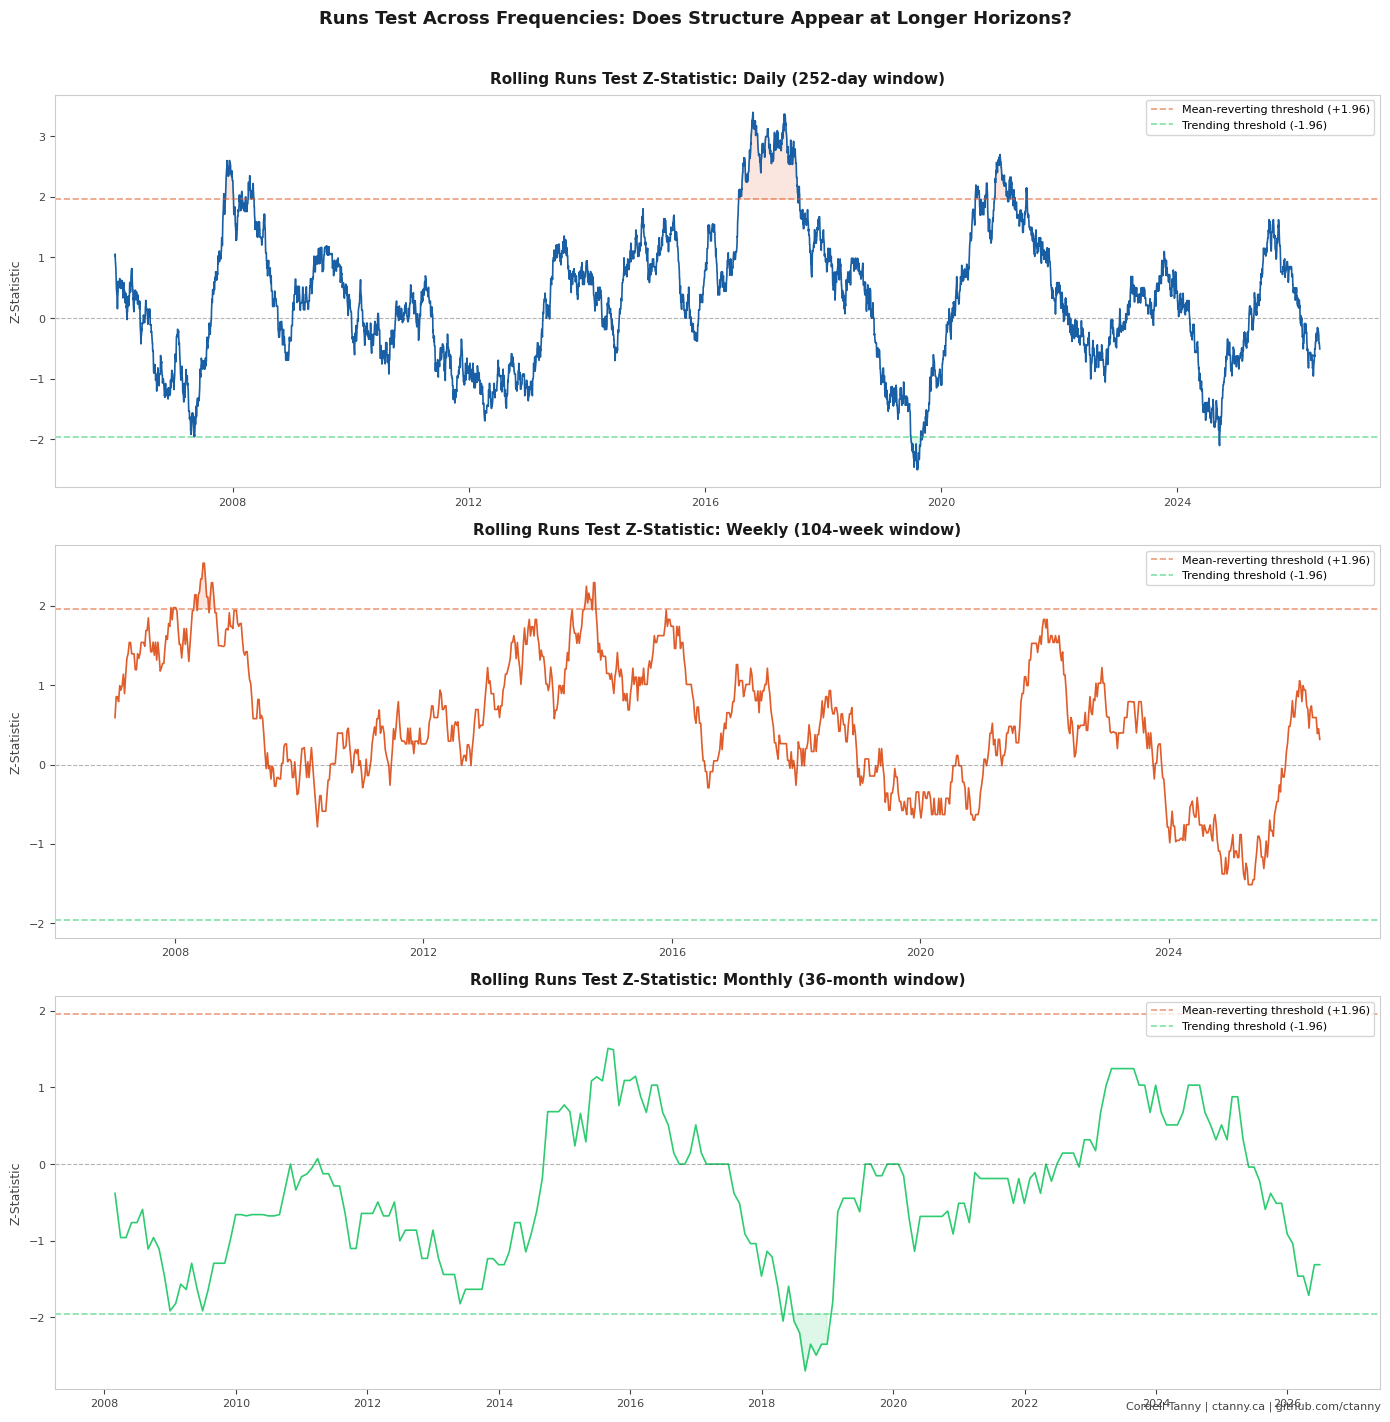

ROLLING TEST SUMMARY BY FREQUENCY
Daily (252-obs window):
  Random         : 90.4%
  Trending       : 1.0%
  Mean-reverting : 8.6%

Weekly (104-obs window):
  Random         : 97.3%
  Trending       : 0.0%
  Mean-reverting : 2.7%

Monthly (36-obs window):
  Random         : 96.4%
  Trending       : 3.6%
  Mean-reverting : 0.0%



In [7]:
# Rolling runs test at weekly and monthly frequency
ROLLING_WEEKLY  = 104  # 2 years of weekly data
ROLLING_MONTHLY = 36   # 3 years of monthly data

def rolling_runs(returns, window):
    """Compute rolling runs test results across a return series."""
    results = []
    r_vals  = returns.values
    r_index = returns.index
    for i in range(window, len(r_vals)):
        w   = r_vals[i - window: i]
        res = runs_test(w)
        results.append({
            'date'   : r_index[i],
            'z_stat' : res['z_stat'],
            'p_value': res['p_value'],
        })
    return pd.DataFrame(results).set_index('date')


df_weekly  = rolling_runs(returns_weekly,  ROLLING_WEEKLY)
df_monthly = rolling_runs(returns_monthly, ROLLING_MONTHLY)

# Three-panel comparison chart
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.patch.set_facecolor('white')

configs = [
    (df_roll,    'Daily (252-day window)',    '#185FA5'),
    (df_weekly,  'Weekly (104-week window)',  '#E05C2A'),
    (df_monthly, 'Monthly (36-month window)', '#2ECC71'),
]

for ax, (df, title, color) in zip(axes, configs):
    ax.set_facecolor('white')
    ax.plot(df.index, df['z_stat'], color=color, linewidth=1.2)
    ax.axhline(0,     color='#444444', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.axhline(1.96,  color='#E05C2A', linewidth=1.2, linestyle='--',
               alpha=0.6, label='Mean-reverting threshold (+1.96)')
    ax.axhline(-1.96, color='#2ECC71', linewidth=1.2, linestyle='--',
               alpha=0.6, label='Trending threshold (-1.96)')
    ax.fill_between(df.index, df['z_stat'],  1.96,
                    where=df['z_stat'] >  1.96,
                    color='#E05C2A', alpha=0.15)
    ax.fill_between(df.index, df['z_stat'], -1.96,
                    where=df['z_stat'] < -1.96,
                    color='#2ECC71', alpha=0.15)
    ax.set_title(f'Rolling Runs Test Z-Statistic: {title}',
                 fontsize=11, fontweight='bold', color='#1a1a1a', pad=8)
    ax.set_ylabel('Z-Statistic', fontsize=9, color='#444444')
    ax.legend(fontsize=8, frameon=True, facecolor='white',
              edgecolor='#cccccc', loc='upper right')
    ax.tick_params(colors='#444444', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#cccccc')

plt.suptitle('Runs Test Across Frequencies: Does Structure Appear at Longer Horizons?',
             fontsize=13, fontweight='bold', color='#1a1a1a', y=1.01)
plt.figtext(0.99, 0.01, 'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#444444', fontsize=8)
plt.tight_layout()
plt.savefig('runs_frequency_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# Summary stats per frequency
print("ROLLING TEST SUMMARY BY FREQUENCY")
print("=" * 60)
for df, label, window in [
    (df_roll,    'Daily',   252),
    (df_weekly,  'Weekly',  ROLLING_WEEKLY),
    (df_monthly, 'Monthly', ROLLING_MONTHLY)
]:
    pct_nr  = (df['p_value'] < ALPHA).mean()
    pct_tr  = ((df['p_value'] < ALPHA) & (df['z_stat'] < 0)).mean()
    pct_mr  = ((df['p_value'] < ALPHA) & (df['z_stat'] > 0)).mean()
    print(f"{label} ({window}-obs window):")
    print(f"  Random         : {1-pct_nr:.1%}")
    print(f"  Trending       : {pct_tr:.1%}")
    print(f"  Mean-reverting : {pct_mr:.1%}")
    print()


All three frequencies tell the same story. The full-sample test
cannot reject randomness at daily, weekly, or monthly horizons.
The rolling tests confirm it: SPY spends roughly 90% or more of
its time in windows that look random regardless of how you slice
the data.

This might seem to contradict something obvious: prices trend.
Anyone who has looked at a 20-year SPY chart knows that. So what
is going on?

The runs test only looks at the sign of each return, not its size.
A market can trend strongly while the sequence of up and down days
looks completely random, because trending is driven by the magnitude
of moves, not their frequency. During a bull market you might get
a large up day, a small down day, another up day, another small
down day. Signs alternate constantly but prices drift steadily
higher because the up days are bigger than the down days. The runs
test sees the alternation and calls it random. It is not wrong.
It is just answering a different question than you thought you
were asking.

The monthly chart is the most honest of the three. Around 2018 to
2019 the z-statistic briefly approaches the trending threshold,
coinciding with a period of sustained monthly gains in the late
bull market. That is the closest this test gets to detecting what
everyone intuitively knows about SPY. And even then, it does not
cross the significance line.

So when should you use this test? Not to detect whether prices
trend. That is the wrong question for a sign-based test. The runs
test earns its place when the information you care about is in the
sequence of outcomes rather than their size. Did my strategy
produce wins and losses in a random pattern or are the losses
clustering? Is my signal generator alternating between buy and
sell in a way that suggests regime dependence? Are monthly
economic surprises coming in above or below consensus in
non-random streaks? Those are questions where the magnitude of
each observation is irrelevant and the sequence structure is
everything. For those questions, the runs test is exactly the
right tool.

The broader lesson applies to every statistical test in finance.
Each one is asking a very specific and narrow question. The runs
test is a good test. It just happens to answer a question that
turns out to be less informative for return series than it first
appears, and knowing that distinction is more valuable than the
test result itself.

## 6. Key Takeaways

1. The runs test looks at sequence structure, not magnitude.

Autocorrelation tests for linear dependence between return levels.
The runs test only asks whether the sequence of ups and downs looks
random. These are complementary but very different questions. A
series can trend strongly while its sign sequence looks completely
random, because trending is driven by the size of moves, not their
frequency. Knowing what each test is actually measuring is more
important than the result itself.

2. Few runs means trending structure. Many runs means mean reversion.

If the market tends to string together consecutive positive or negative days more than a random process would predict, you have trending structure that a momentum strategy might exploit. If signs flip more frequently than expected, you have mean-reverting structure that a contrarian strategy might exploit. The z-statistic tells you the direction and the p-value tells you whether it is statistically meaningful.

3. Market structure changes over time.

The rolling test is the most practically useful output. A strategy that worked during a period of trending structure may fail when the market shifts to random or mean-reverting behavior. Monitoring the rolling runs test gives you an early warning that the regime your strategy was designed for may be changing.

4. This is a sign-based test with no distribution assumptions.

Unlike many statistical tests used in finance, the runs test makes no assumption about the distribution of returns. It only uses the sign of each return. This makes it robust to the fat tails and non-normality we documented in the first notebook of this series.

5. Use it as one tool among many.

The runs test tells you about the sequential structure of the sign sequence. It does not capture the magnitude of moves, volatility clustering, or cross-asset dependencies. It is a fast, assumption-free diagnostic that belongs in your toolkit alongside autocorrelation tests, variance ratio tests, and the normality tests from notebook one.

6. Know what your test cannot detect.

SPY is one of the most clearly trending assets in financial history
over the past 20 years. The runs test called it random at every
frequency. That is not a flaw in the test. It is a reminder that
every statistical tool answers a precise and narrow question, and
applying it outside that scope produces results that are technically
correct and practically misleading. The runs test belongs in your
toolkit for evaluating strategy win/loss sequences, signal
clustering, and categorical financial data where magnitude is
irrelevant and sequence is everything.


---

What comes next:

A natural companion to the runs test is the variance ratio test, which tests the random walk hypothesis more formally and is directly relevant to whether momentum effects are statistically detectable in a given asset or time period.

---

*Cordell Tanny, CFA, FRM, FDP*  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny/quant-finance-snippets](https://github.com/ctanny/quant-finance-snippets)  
*Questions or ideas? Connect on LinkedIn.*

---

*This notebook is for educational and informational purposes only. Nothing contained here constitutes investment advice, a solicitation, or a recommendation to buy or sell any security or financial instrument. The analysis uses historical data to illustrate statistical concepts, not to predict future market behavior. Past performance is not indicative of future results. Readers should consult a qualified financial professional before making any investment decisions.*